In [1]:
import pandas as pd
import sqlite3

In [2]:
df = pd.read_csv('retail_sales_dataset.csv')

print(df.head(15))

     order_id  order_date customer_id  customer_name   age  gender   region  \
0   ORD-03903  2024-08-15   CUST32603    Aarav Mehta  39.0   Other  Central   
1   ORD-02198  2022-08-16   CUST07881   Sanjay Verma  28.0    Male     West   
2   ORD-01348  2021-08-29   CUST49296   Pooja Sharma  41.0   Other     West   
3   ORD-02076  2022-07-05   CUST05587    Priya Reddy  29.0   Other     West   
4   ORD-00287  2020-05-07   CUST58035    Ritu Sharma   9.0    Male  Central   
5   ORD-03954  02/09/2024   CUST17187    Vikram Iyer  29.0    Male     West   
6   ORD-01412  2021-09-28   CUST02453     Arjun Shah  31.0  Female  Central   
7   ORD-02911  2023-06-10   CUST23285  Aditya Sharma  43.0  Female    North   
8   ORD-00465  2020-07-24   CUST23609   Aditya Patel  44.0  Female     East   
9   ORD-00105  2020-02-09   CUST75337      Arjun Das  17.0  FEMALE     East   
10  ORD-00362  2020-06-04   CUST80340   Meera Mishra  51.0   Other  Central   
11  ORD-01701  2022-01-28   CUST47772    Shreya Bose

# INTRODUCTION

This dataset contains retail sales data for products sold across India. It includes detailed information about customer orders, such as product price, sales amount, order date, city, region, and other relevant attributes.

The main objective is to clean the dataset, perform exploratory data analysis (EDA), identify meaningful insights and trends, and provide actionable business recommendations based on the findings.

# info function(null value check)

In [3]:
# Checking the null values in the data 

In [4]:
print(df.info()) # checking the data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4280 non-null   object 
 1   order_date             4280 non-null   object 
 2   customer_id            4280 non-null   object 
 3   customer_name          4280 non-null   object 
 4   age                    4150 non-null   float64
 5   gender                 4280 non-null   object 
 6   region                 4280 non-null   object 
 7   city                   4280 non-null   object 
 8   product_category       4280 non-null   object 
 9   product_name           4280 non-null   object 
 10  quantity               4170 non-null   float64
 11  unit_price             4280 non-null   float64
 12  discount_pct           4143 non-null   float64
 13  sales_amount           4280 non-null   float64
 14  profit                 4280 non-null   float64
 15  ship

* From this we can see that order date is object instead of datetime
* age is in float instead of int
* And some NaN values

In [5]:
print(df.isnull().sum())

order_id                  30
order_date                30
customer_id               30
customer_name             30
age                      160
gender                    30
region                    30
city                      30
product_category          30
product_name              30
quantity                 140
unit_price                30
discount_pct             167
sales_amount              30
profit                    30
shipping_cost             30
payment_method            30
customer_satisfaction    378
return_flag               30
order_status              30
days_to_ship             130
dtype: int64


# STATITICS CLEAN

now we will check the statatics in the data

In [6]:
print(df.describe())

               age     quantity    unit_price  discount_pct  sales_amount  \
count  4150.000000  4170.000000   4280.000000   4143.000000  4.280000e+03   
mean     35.335181     7.379856  10621.154428      0.202085  6.235864e+04   
std      35.709382    43.578352  17323.704016      0.118095  3.166998e+05   
min      -7.000000    -1.000000     50.260000      0.000000  3.945000e+01   
25%      26.000000     3.000000    672.222500      0.100000  2.462165e+03   
50%      34.000000     5.000000   2228.435000      0.210000  9.548075e+03   
75%      42.000000     8.000000  12717.435000      0.310000  5.006964e+04   
max     999.000000   999.000000  79957.920000      0.400000  1.736031e+07   

             profit  shipping_cost  customer_satisfaction  days_to_ship  
count  4.280000e+03    4280.000000            3932.000000   4180.000000  
mean   1.168713e+04      63.358836               3.016531      5.620335  
std    5.287522e+04      18.312281               1.413127      4.178663  
min    1.5

As we can see there are many errors
* There are negative numbers in age , quantity , shipping cost , days to ship 
* max age is 999 which is impossible 
* profit and sales amount is in scientific notation
* days to ship is 100 while average is 4 and its very suspicious 

In [7]:
# Fixing all of the errors - 

# negative values 
df['age'] = df['age'].where(df['age'] > 0 , df['age'] < 120)
# print(df['quantity'].where(df['quantity'] > 90).dropna()) after checking  this we got 5 999 values 

# highest_below_999 = df['quantity'][df['quantity'] < 999].max()
# print(highest_below_999) # to get the highest value below 999

df['quantity'] = df['quantity'].where(df['quantity'] > 0 , df['quantity'] < 11 )

df['shipping_cost'] = df['shipping_cost'].where(df['shipping_cost'] > 0 , df['shipping_cost'] < 134)

# highest_below_100 = df['days_to_ship'][df['days_to_ship'] < 100].max() 
# print(highest_below_100)


df['days_to_ship'] = df['days_to_ship'].where(df['days_to_ship'] > 0 , df['days_to_ship'] < 46)

# To get the normal nums instead of scientific notation
# print(df.describe().round(2))

df['order_date'] = pd.to_datetime(df['order_date'] , errors = 'coerce')
df['order_date'] = df['order_date'].fillna('Unknown')

print(df['region'].isnull().sum())
df = df.dropna(subset = ['region'])
print(df['region'].isnull().sum())

df['region'] = df['region'].fillna('Unknown')


print(df.info())

print("Everything fixed!!!!")

# I COMMENTED OUT THE CODE WE DONT NEED NOW 
 

30
0
<class 'pandas.core.frame.DataFrame'>
Index: 4280 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4280 non-null   object 
 1   order_date             4280 non-null   object 
 2   customer_id            4280 non-null   object 
 3   customer_name          4280 non-null   object 
 4   age                    4280 non-null   object 
 5   gender                 4280 non-null   object 
 6   region                 4280 non-null   object 
 7   city                   4280 non-null   object 
 8   product_category       4280 non-null   object 
 9   product_name           4280 non-null   object 
 10  quantity               4280 non-null   object 
 11  unit_price             4280 non-null   float64
 12  discount_pct           4143 non-null   float64
 13  sales_amount           4280 non-null   float64
 14  profit                 4280 non-null   float64
 15  ship

In [8]:
# we can see that there are many null values to remove in all colomns 





In [9]:
# now we will check the shape of the data
print(df.shape)

(4280, 21)


there are 21 colomns and 4310 rows

# REMOVING NULL VALUES

In [10]:
rows_null = df[df['order_id'].isnull()]
print(rows_null)

Empty DataFrame
Columns: [order_id, order_date, customer_id, customer_name, age, gender, region, city, product_category, product_name, quantity, unit_price, discount_pct, sales_amount, profit, shipping_cost, payment_method, customer_satisfaction, return_flag, order_status, days_to_ship]
Index: []

[0 rows x 21 columns]


In [11]:
df = df.dropna(how = 'all')

print(df.isnull().sum())


order_id                   0
order_date                 0
customer_id                0
customer_name              0
age                        0
gender                     0
region                     0
city                       0
product_category           0
product_name               0
quantity                   0
unit_price                 0
discount_pct             137
sales_amount               0
profit                     0
shipping_cost              0
payment_method             0
customer_satisfaction    348
return_flag                0
order_status               0
days_to_ship               0
dtype: int64


In [12]:
df['age'] = df['age'].fillna(df['age'].mean())
df['quantity'] = df['quantity'].fillna(df['quantity'].mean())
df['discount_pct'] = df['discount_pct'].fillna(df['discount_pct'].median())
df['customer_satisfaction'] = df['customer_satisfaction'].fillna(df['customer_satisfaction'].median())
df['days_to_ship'] = df['days_to_ship'].fillna(df['days_to_ship'].mean())

print(df.isnull().sum())
print('ALL NaN VALUES CLEARED!!!')

order_id                 0
order_date               0
customer_id              0
customer_name            0
age                      0
gender                   0
region                   0
city                     0
product_category         0
product_name             0
quantity                 0
unit_price               0
discount_pct             0
sales_amount             0
profit                   0
shipping_cost            0
payment_method           0
customer_satisfaction    0
return_flag              0
order_status             0
days_to_ship             0
dtype: int64
ALL NaN VALUES CLEARED!!!


# SQL INFO

In [13]:
df['order_date'] = df['order_date'].astype(str)
conn = sqlite3.connect('sales.db')
df.to_sql('sales_data',conn,index = False , if_exists ='replace')

# making queries
query = 'SELECT "region" , AVG("unit_price") as avg_price FROM sales_data GROUP BY region ORDER BY avg_price DESC'

query2 = 'SELECT "city" , AVG("unit_price") as avg_price FROM sales_data GROUP BY city ORDER BY avg_price DESC LIMIT 5'

query3 = 'SELECT "city" , AVG("profit") as avg_profit FROM  sales_data GROUP BY city  ORDER BY avg_profit DESC LIMIT 5'

query4 =  'SELECT "city" , AVG("days_to_ship") as avg_ship FROM  sales_data GROUP BY city  ORDER BY avg_ship DESC LIMIT 5'


print(pd.read_sql_query(query,conn))

print('--'*90)
                        
print(pd.read_sql_query(query2,conn))

print('--'*90)

print(pd.read_sql_query(query3,conn))

print('--'*90)

print(pd.read_sql_query(query4,conn))

    region     avg_price
0     East  11371.895402
1    South  10896.743356
2     West  10608.959068
3    North  10416.302156
4  Central   9755.834517
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
          city     avg_price
0       Bhopal  12228.792881
1      Kolkata  11837.048380
2      Chennai  11808.704937
3  Bhubaneswar  11795.315722
4    Hyderabad  11698.360089
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
       city    avg_profit
0     Kochi  22278.503510
1  Amritsar  17241.612355
2   Chennai  17199.899163
3    Indore  12929.422222
4     Patna  11419.726816
--------------------------------------------------------------------------------------------------------------------------------------------------------------

### Key Insights from the Analysis

* **East** has the **highest average product price** among all regions.
* **Bhopal** has the **highest average product price** among all cities.
* **Kochi** records the **highest average profit** among all cities.
* **Patna** has the **highest average shipping time** (days to ship), indicating that orders to this city take the longest to be delivered on average.


# PANDAS 

In [16]:
df['gender'] = df['gender'].str.strip().str.lower().str.title()

df['gender'] = df['gender'].replace({'m':'Male' , 'f':'Female','F':'Female' , 'M':'Male'})

print(df['gender'].value_counts())

print('--'*90)

print(df['region'].value_counts())

print('--'*90)

print(df['payment_method'].value_counts())

print('--'*90)

print(df['product_category'].value_counts())

gender
Other     1442
Male      1442
Female    1396
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
region
South      885
West       880
North      872
East       846
Central    797
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
payment_method
UPI                 761
Credit Card         734
Cash on Delivery    717
Debit Card          700
EMI                 695
Net Banking         673
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
product_category
Clothing       645
Groceries      627
Sports         625
Electronics 

### Key Insights from the Pandas Analysis

* The dataset contains **1,442 male customers**, **1,442 customers categorized as "Other"**, and **1,396 female customers**.
* **South** is the region with the **highest number of orders**.
* **UPI** is the **most frequently used payment method**.
* **Clothing** is the **most purchased product category**.


# PLOTTING 

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

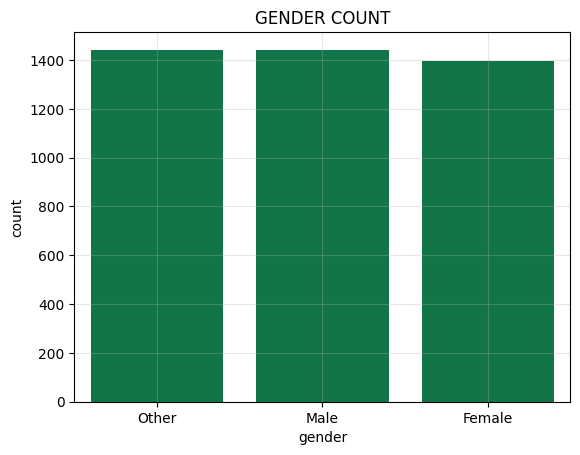

In [21]:
sns.countplot(data = df , x = 'gender' , color = '#01854a')
plt.title('GENDER COUNT')
plt.grid(True , alpha = 0.3)
plt.show()

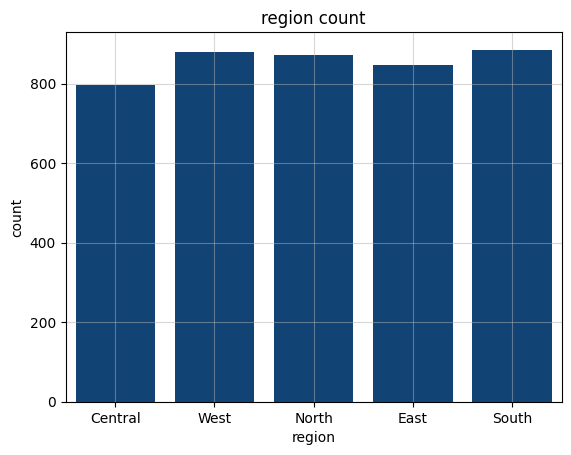

In [22]:
sns.countplot(data = df , x = 'region' , color = '#014385')
plt.title('region count')
plt.grid(True , alpha = 0.5)
plt.show()

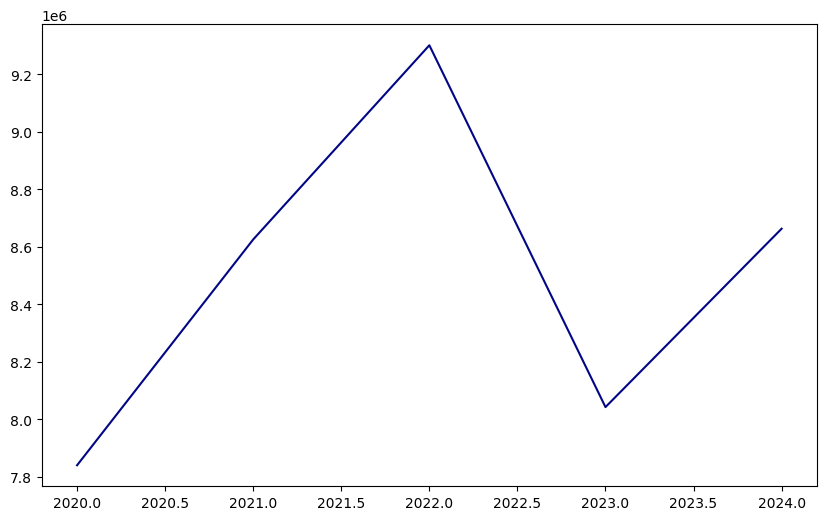

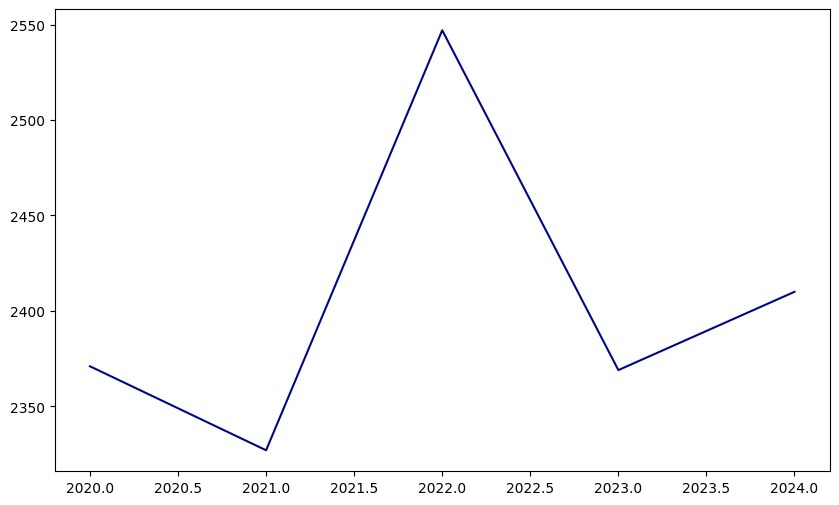

In [41]:
df['order_date'] = pd.to_datetime(df['order_date'] , errors = 'coerce')
df['years'] = (df['order_date'].dt.year)

years_avg_p = df.groupby('years')['unit_price'].sum()

plt.figure(figsize = (10,6))
plt.plot(years_avg_p.index , years_avg_p.values ,  color = '#010685')
plt.show()

df['order_date'] = pd.to_datetime(df['order_date'] , errors = 'coerce')
df['years'] = (df['order_date'].dt.year)

years_avg_s = df.groupby('years')['customer_satisfaction'].sum()

plt.figure(figsize = (10,6))
plt.plot(years_avg_s.index , years_avg_s.values ,  color = '#010685')
plt.show()

### Correlation Analysis

The correlation analysis was performed to examine the relationships between the **numeric variables** in the dataset. It helps identify whether two variables move together, move in opposite directions, or have little to no relationship.

* A **positive correlation** indicates that as one variable increases, the other also tends to increase.
* A **negative correlation** indicates that as one variable increases, the other tends to decrease.
* A correlation value **close to 0** suggests little or no linear relationship between the variables.


In [33]:
print(df.corr(numeric_only = True))

                       unit_price  discount_pct  sales_amount    profit  \
unit_price               1.000000     -0.022142      0.295509  0.233631   
discount_pct            -0.022142      1.000000     -0.047078 -0.046581   
sales_amount             0.295509     -0.047078      1.000000  0.948788   
profit                   0.233631     -0.046581      0.948788  1.000000   
customer_satisfaction   -0.011571     -0.006863     -0.025436 -0.024249   
years                    0.007479      0.019917      0.011216  0.004635   

                       customer_satisfaction     years  
unit_price                         -0.011571  0.007479  
discount_pct                       -0.006863  0.019917  
sales_amount                       -0.025436  0.011216  
profit                             -0.024249  0.004635  
customer_satisfaction               1.000000  0.003157  
years                               0.003157  1.000000  


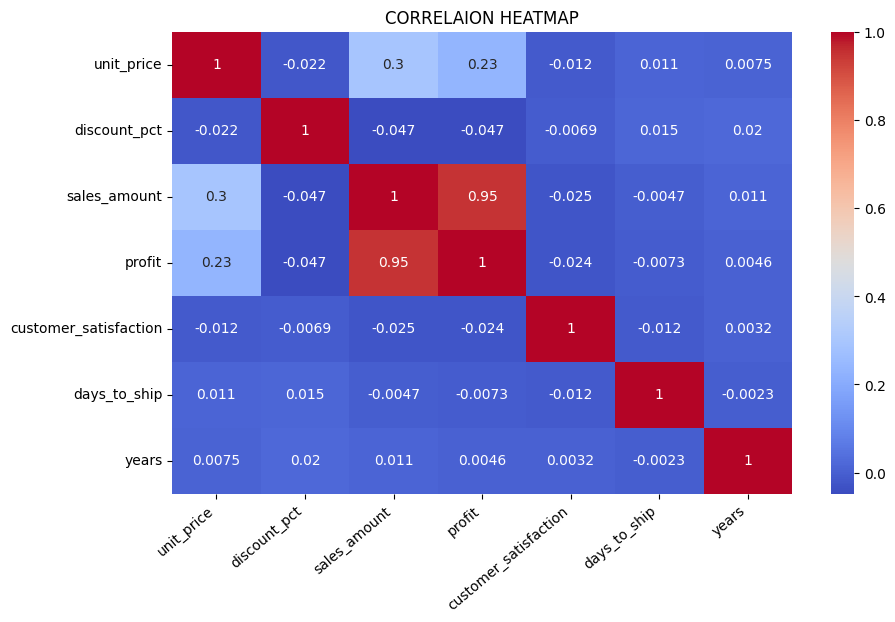

In [53]:
df['days_to_ship'] = df['days_to_ship'].astype(int)

corr = df.corr(numeric_only = True)

plt.figure(figsize = (10,6))
sns.heatmap(corr , annot = True , cmap = 'coolwarm')
plt.title('CORRELAION HEATMAP')
plt.xticks(rotation = 40 , ha = 'right')
plt.show()

In [37]:
# jackpot

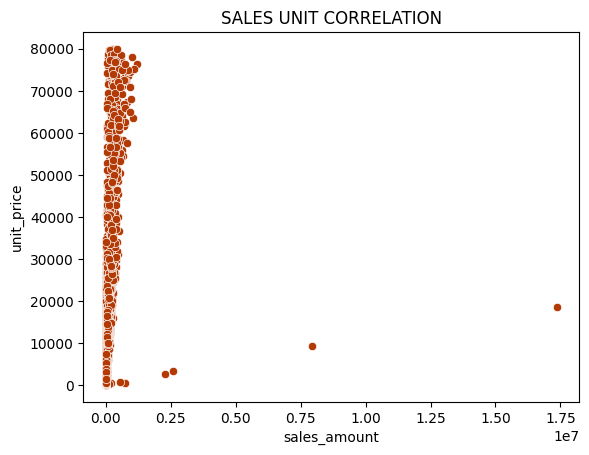

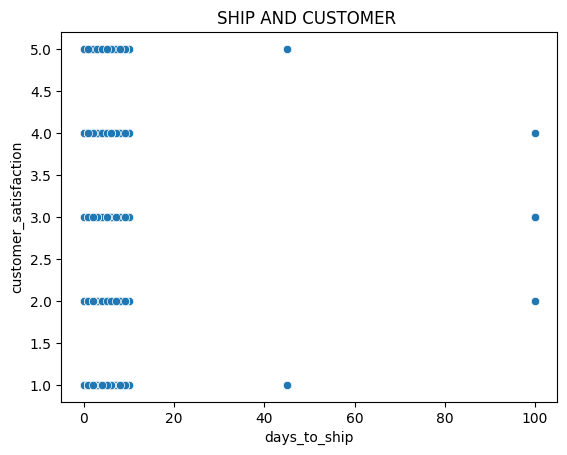

In [54]:
sns.scatterplot(data = df , x = 'sales_amount' , y = 'unit_price' , color = '#b33905')
plt.title('SALES UNIT CORRELATION')
plt.show()

sns.scatterplot(data = df , x = 'days_to_ship' , y = 'customer_satisfaction')
plt.title('SHIP AND CUSTOMER ')
plt.show()

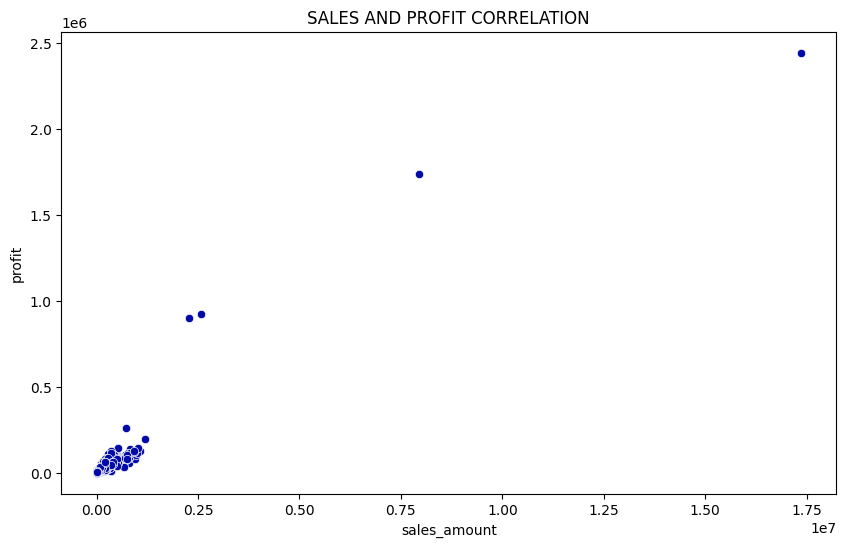

In [40]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = df , x = 'sales_amount' , y = 'profit' , color = '#030ba6')
plt.title('SALES AND PROFIT CORRELATION')
plt.show()

# Final Verdict

Based on the data cleaning, exploratory data analysis (EDA), and visualizations, the following key insights were identified:

* The **South** region records the **highest number of orders**, making it the strongest market in terms of sales volume.
* The **top five cities with the highest average product prices** are:

  1. **Bhopal** – ₹12,228.79
  2. **Kolkata** – ₹11,837.05
  3. **Chennai** – ₹11,808.70
  4. **Bhubaneswar** – ₹11,795.32
  5. **Hyderabad** – ₹11,698.36
* The **highest average product price** was recorded in **2022**, while **2020** had the lowest average price.
* The number of **Male** and **Other** customers in the dataset is identical, while the number of **Female** customers is slightly lower.
* **UPI** is the most frequently used payment method, indicating a strong customer preference for digital payments.
* Customer satisfaction reached its **highest level in 2022** and was **lowest in 2021**.
* An interesting observation is that **shipping time (days to ship) does not appear to have a significant relationship with customer satisfaction**, as supported by the analysis and visualizations.

## Recommendations

* The overall trend suggests positive business growth. If this upward trend continues, increasing marketing and promotional campaigns could help attract more customers and further boost sales.
* **Kochi** and **Amritsar** consistently generate high average profits, making them strong candidates for additional investment, targeted promotions, and inventory expansion.
* Although the **South** region generates the highest number of orders, the **East** region records a higher average product price. This indicates that customers in the East tend to purchase higher-value products, suggesting significant potential for revenue growth through focused marketing and premium product offerings.
* Since **UPI** is the preferred payment method, optimizing the digital checkout experience and offering UPI-based promotions or cashback campaigns could improve customer engagement and conversion rates.
* The lack of a clear relationship between shipping time and customer satisfaction suggests that other factors—such as product quality, pricing, customer service, or return experience—may have a greater influence on customer satisfaction and should be investigated further.
